In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install -q timm

# Copy datasets from Drive
!rm -rf /content/binary_dataset
!rm -rf /content/multiclass_dataset

!cp -r "/content/drive/MyDrive/EarProject/binary_dataset" /content/
!cp -r "/content/drive/MyDrive/EarProject/multiclass_dataset" /content/

# Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Setup Complete")
print("Binary dataset exists:", os.path.exists("/content/binary_dataset"))
print("Multiclass dataset exists:", os.path.exists("/content/multiclass_dataset"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
^C


**EfficientNet-B0 - BINARY CLASSIFICATION**



In [ ]:
from PIL import Image
import os

def remove_corrupted_images(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted:", path)
                os.remove(path)
                removed += 1
    print("Total removed:", removed)

remove_corrupted_images("/content/binary_dataset")

Removing corrupted: /content/binary_dataset/train/Abnormal/ci-90-_jpg.rf.d439d47e971fd106a006a487f47f42b8.jpg
Removing corrupted: /content/binary_dataset/train/Abnormal/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Removing corrupted: /content/binary_dataset/train/Normal/norm-7-_jpg.rf.6f07b92910dad0ad93dae0358966fbc6.jpg
Total removed: 3


In [ ]:
# Loading Binary dataset
train_dir = "/content/binary_dataset/train"
val_dir = "/content/binary_dataset/valid"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


Classes: ['Abnormal', 'Normal']
Train size: 2335
Validation size: 292


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 73
Val batches: 10


In [ ]:
# Creating Binary model
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model_eff_binary = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

in_features = model_eff_binary.classifier[1].in_features
model_eff_binary.classifier[1] = nn.Linear(in_features, 2)

model_eff_binary = model_eff_binary.to(device)

print("EfficientNet-B0 Binary model ready")


EfficientNet-B0 Binary model ready


In [ ]:
for param in model_eff_binary.parameters():
    param.requires_grad = False

for param in model_eff_binary.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion_eff = nn.CrossEntropyLoss(label_smoothing=0.2)

optimizer_eff = torch.optim.Adam(
    model_eff_binary.classifier.parameters(),
    lr=3e-4,
    weight_decay=5e-4
)
print("Optimizer ready")


Optimizer ready


In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):

    # TRAINING
    model_eff_binary.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_eff.zero_grad()
        outputs = model_eff_binary(images)
        loss = criterion_eff(outputs, labels)
        loss.backward()
        optimizer_eff.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model_eff_binary.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_eff_binary(images)
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model_eff_binary.state_dict(),
                   "/content/drive/MyDrive/EarProject/models/efficientnet_binary_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"- Train Loss: {train_loss:.4f} "
          f"- Train Acc: {train_accuracy:.2f}% "
          f"- Val Acc: {val_accuracy:.2f}%")

print("Best Validation Accuracy:", best_val_acc)


Epoch [1/10] - Train Loss: 0.5705 - Train Acc: 78.42% - Val Acc: 85.96%
Epoch [2/10] - Train Loss: 0.4900 - Train Acc: 85.44% - Val Acc: 89.38%
Epoch [3/10] - Train Loss: 0.4618 - Train Acc: 89.72% - Val Acc: 90.41%
Epoch [4/10] - Train Loss: 0.4535 - Train Acc: 89.76% - Val Acc: 90.75%
Epoch [5/10] - Train Loss: 0.4441 - Train Acc: 91.43% - Val Acc: 91.10%
Epoch [6/10] - Train Loss: 0.4352 - Train Acc: 92.08% - Val Acc: 92.12%
Epoch [7/10] - Train Loss: 0.4272 - Train Acc: 92.81% - Val Acc: 92.12%
Epoch [8/10] - Train Loss: 0.4266 - Train Acc: 92.89% - Val Acc: 92.12%
Epoch [9/10] - Train Loss: 0.4270 - Train Acc: 93.15% - Val Acc: 91.78%
Epoch [10/10] - Train Loss: 0.4310 - Train Acc: 91.69% - Val Acc: 91.78%
Best Validation Accuracy: 92.12328767123287


In [ ]:

test_dir = "/content/binary_dataset/test"
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_eff_binary.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_eff_binary(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Total Test Samples:", total)
print("Correct Predictions:", correct)
print("Test Accuracy: {:.2f}%".format(test_accuracy))


Total Test Samples: 292
Correct Predictions: 268
Test Accuracy: 91.78%


In [ ]:
import os

save_dir = "/content/drive/MyDrive/EarProject/models"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_eff_binary.state_dict(),
           "/content/drive/MyDrive/EarProject/models/efficientnet_b0_binary_best.pth")

print("EfficientNet-B0 Binary model saved successfully!")


EfficientNet-B0 Binary model saved successfully!


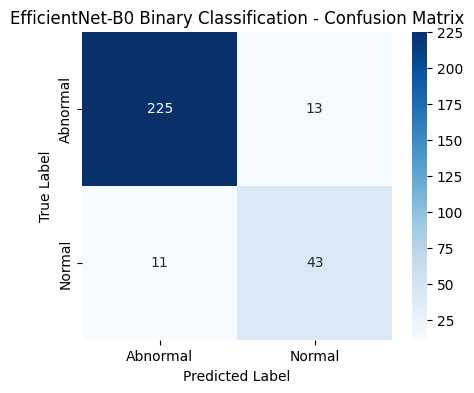


Classification Report:

              precision    recall  f1-score   support

    Abnormal       0.95      0.95      0.95       238
      Normal       0.77      0.80      0.78        54

    accuracy                           0.92       292
   macro avg       0.86      0.87      0.87       292
weighted avg       0.92      0.92      0.92       292



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model_eff_binary.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_eff_binary(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Binary Classification - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes))


**EfficientNet-B0 - MULTICLASS CLASSIFICATION**


In [ ]:
!rm -rf /content/ear_dataset
!cp -r "/content/drive/MyDrive/Ear Diseases/Dataset/extracted" /content/ear_dataset
print("Original ear_dataset restored")


Original ear_dataset restored


In [ ]:
import json

ann_path = "/content/ear_dataset/train/_annotations.coco.json"
new_ann_path = "/content/ear_dataset/train/_annotations_filtered.coco.json"

with open(ann_path) as f:
    data = json.load(f)

filtered_categories = [c for c in data['categories'] if c['name'] != 'ear_conditions-zL5Z']
data['categories'] = filtered_categories

valid_ids = [c['id'] for c in filtered_categories]
data['annotations'] = [a for a in data['annotations'] if a['category_id'] in valid_ids]

with open(new_ann_path, "w") as f:
    json.dump(data, f)

print("Filtered annotation recreated")


Filtered annotation recreated


In [ ]:
import os, json, shutil
from collections import defaultdict

base_dir = "/content/ear_dataset"
multi_dir = "/content/multiclass_dataset"

!rm -rf /content/multiclass_dataset

splits = ["train", "valid", "test"]

disease_map = {
    "aom": "AOM",
    "ci": "CI",
    "com": "COM",
    "mys": "MYS"
}

for split in splits:
    for d in disease_map.values():
        os.makedirs(f"{multi_dir}/{split}/{d}", exist_ok=True)

    ann_path = f"{base_dir}/{split}/_annotations.coco.json"
    if split == "train":
        ann_path = f"{base_dir}/{split}/_annotations_filtered.coco.json"

    with open(ann_path) as f:
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}
    img_map = {img['id']: img['file_name'] for img in data['images']}

    img_labels = defaultdict(set)
    for ann in data['annotations']:
        img_labels[ann['image_id']].add(cat_map[ann['category_id']])

    for img_id, labels in img_labels.items():
        file_name = img_map[img_id]
        src = f"{base_dir}/{split}/{file_name}"

        diseases = [l for l in labels if l in disease_map]

        if len(diseases) == 1:
            dst = f"{multi_dir}/{split}/{disease_map[diseases[0]]}/{file_name}"
            if os.path.exists(src):
                shutil.copy(src, dst)

print("Multiclass dataset recreated successfully!")


Multiclass dataset recreated successfully!


In [ ]:
remove_corrupted_images("/content/multiclass_dataset")


Removing corrupted: /content/multiclass_dataset/train/AOM/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Total removed: 1


In [ ]:
for cls in ["AOM", "CI", "COM", "MYS"]:
    print(cls, ":", len(os.listdir(f"/content/multiclass_dataset/train/{cls}")))

print("Validation Total:",
      sum(len(os.listdir(f"/content/multiclass_dataset/valid/{cls}"))
          for cls in ["AOM", "CI", "COM", "MYS"]))


AOM : 419
CI : 474
COM : 484
MYS : 491
Validation Total: 215


In [ ]:
train_dir_multi = "/content/multiclass_dataset/train"
val_dir_multi = "/content/multiclass_dataset/valid"

train_dataset_multi = datasets.ImageFolder(train_dir_multi, transform=train_transforms)
val_dataset_multi = datasets.ImageFolder(val_dir_multi, transform=val_transforms)

print("Classes:", train_dataset_multi.classes)
print("Train size:", len(train_dataset_multi))
print("Validation size:", len(val_dataset_multi))


Classes: ['AOM', 'CI', 'COM', 'MYS']
Train size: 1868
Validation size: 215


In [ ]:
train_loader_multi = DataLoader(train_dataset_multi, batch_size=32, shuffle=True, num_workers=2)
val_loader_multi = DataLoader(val_dataset_multi, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader_multi))
print("Validation batches:", len(val_loader_multi))


Train batches: 59
Validation batches: 7


In [ ]:

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

model_eff_multi = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

in_features = model_eff_multi.classifier[1].in_features
model_eff_multi.classifier[1] = nn.Linear(in_features, 4)

for param in model_eff_multi.parameters():
    param.requires_grad = False

for param in model_eff_multi.classifier.parameters():
    param.requires_grad = True

model_eff_multi = model_eff_multi.to(device)

print("EfficientNett-B0 Multi class Model ready")

EfficientNett-B0 Multi class Model ready


In [ ]:
criterion_multi = nn.CrossEntropyLoss()

optimizer_multi = torch.optim.Adam(
    model_eff_multi.classifier.parameters(),
    lr=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:

num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):

    # TRAINING
    model_eff_multi.train()
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)

        optimizer_multi.zero_grad()
        outputs = model_eff_multi(images)
        loss = criterion_multi(outputs, labels)
        loss.backward()
        optimizer_multi.step()

        _, preds = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (preds == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # VALIDATION
    model_eff_multi.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader_multi:
            images, labels = images.to(device), labels.to(device)
            outputs = model_eff_multi(images)
            _, preds = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model_eff_multi.state_dict(),
            "/content/drive/MyDrive/EarProject/models/efficientnet_multiclass_best.pth"
        )

    print(f"Epoch [{epoch+1}/10] "
          f"- Train Acc: {train_acc:.2f}% "
          f"- Val Acc: {val_acc:.2f}%")

print("Best Validation Accuracy:", best_val_acc)

Epoch [1/10] - Train Acc: 69.33% - Val Acc: 82.79%
Epoch [2/10] - Train Acc: 83.99% - Val Acc: 87.91%
Epoch [3/10] - Train Acc: 90.15% - Val Acc: 91.63%
Epoch [4/10] - Train Acc: 91.17% - Val Acc: 93.49%
Epoch [5/10] - Train Acc: 92.40% - Val Acc: 92.56%
Epoch [6/10] - Train Acc: 92.13% - Val Acc: 93.49%
Epoch [7/10] - Train Acc: 92.88% - Val Acc: 95.35%
Epoch [8/10] - Train Acc: 92.72% - Val Acc: 93.95%
Epoch [9/10] - Train Acc: 94.54% - Val Acc: 94.88%
Epoch [10/10] - Train Acc: 94.43% - Val Acc: 94.88%
Best Validation Accuracy: 95.34883720930233


In [ ]:
# Define test directory
test_dir_multi = "/content/multiclass_dataset/test"

test_dataset_multi = datasets.ImageFolder(test_dir_multi, transform=val_transforms)
test_loader_multi = DataLoader(test_dataset_multi, batch_size=32, shuffle=False)

model_eff_multi.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_multi:
        images, labels = images.to(device), labels.to(device)
        outputs = model_eff_multi(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Total Test Samples:", total)
print("Correct Predictions:", correct)
print("Test Accuracy: {:.2f}%".format(test_accuracy))


Total Test Samples: 238
Correct Predictions: 227
Test Accuracy: 95.38%


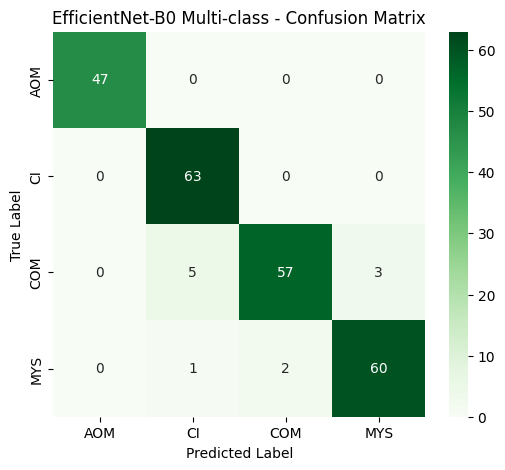


Classification Report:

              precision    recall  f1-score   support

         AOM       1.00      1.00      1.00        47
          CI       0.91      1.00      0.95        63
         COM       0.97      0.88      0.92        65
         MYS       0.95      0.95      0.95        63

    accuracy                           0.95       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.95      0.95       238



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model_eff_multi.eval()

with torch.no_grad():
    for images, labels in test_loader_multi:
        images = images.to(device)
        outputs = model_eff_multi(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=test_dataset_multi.classes,
            yticklabels=test_dataset_multi.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Multi-class - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset_multi.classes))


In [ ]:
import os

save_dir = "/content/drive/MyDrive/EarProject/models"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_eff_multi.state_dict(),
           "/content/drive/MyDrive/EarProject/models/efficientnet_b0_multiclass_best.pth")

print("EfficientNet-B0 Multi-class model saved successfully!")


EfficientNet-B0 Multi-class model saved successfully!


In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn.functional as F

# Load Binary Model
binary_model = efficientnet_b0(weights=None)
in_features = binary_model.classifier[1].in_features
binary_model.classifier[1] = nn.Linear(in_features, 2)

binary_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/efficientnet_b0_binary_best.pth"
))
binary_model = binary_model.to(device)
binary_model.eval()

# Load Multi-class Model
multi_model = efficientnet_b0(weights=None)
in_features = multi_model.classifier[1].in_features
multi_model.classifier[1] = nn.Linear(in_features, 4)

multi_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/efficientnet_b0_multiclass_best.pth"
))
multi_model = multi_model.to(device)
multi_model.eval()

print("Both EfficientNet models loaded successfully!")


Both EfficientNet models loaded successfully!


In [ ]:
disease_full_names = {
    "AOM": "Acute Otitis Media (AOM)",
    "CI": "Chronic Inflammation (CI)",
    "COM": "Chronic Otitis Media (COM)",
    "MYS": "Myringitis (MYS)"
}


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

def predict_ear_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Show image
    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input Ear Image")
    plt.show()

    img_tensor = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        binary_output = binary_model(img_tensor)
        binary_probs = F.softmax(binary_output, dim=1)
        binary_conf, binary_pred = torch.max(binary_probs, 1)

    binary_class = ["Abnormal", "Normal"][binary_pred.item()]
    binary_confidence = binary_conf.item() * 100

    print("Binary Prediction:", binary_class)
    print("Confidence: {:.2f}%".format(binary_confidence))

    # If Normal → Stop
    if binary_class == "Normal":
        print("\nEar looks Normal. No disease detected.")
        return

    with torch.no_grad():
        multi_output = multi_model(img_tensor)
        multi_probs = F.softmax(multi_output, dim=1)
        multi_conf, multi_pred = torch.max(multi_probs, 1)

    disease_class = train_dataset_multi.classes[multi_pred.item()]
    disease_name = disease_full_names[disease_class]
    disease_confidence = multi_conf.item() * 100

    print("\nDisease Type:", disease_name)
    print("Disease Confidence: {:.2f}%".format(disease_confidence))

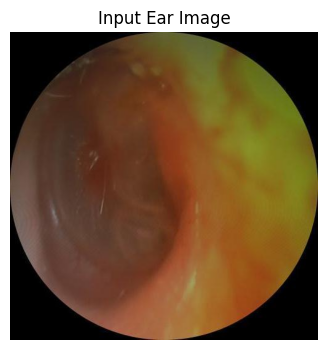

Binary Prediction: Abnormal
Confidence: 78.76%

Disease Type: Acute Otitis Media (AOM)
Disease Confidence: 84.18%


In [ ]:
predict_ear_image("/content/multiclass_dataset/test/AOM/aom-113-_jpg.rf.c380dccd5dae162d26bc877cfd4e515a.jpg")


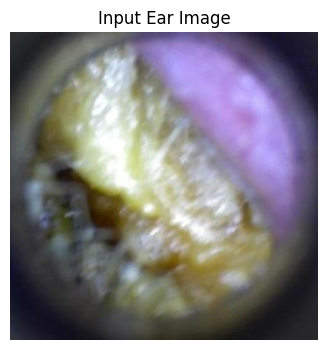

Binary Prediction: Abnormal
Confidence: 83.19%

Disease Type: Chronic Inflammation (CI)
Disease Confidence: 89.62%


In [ ]:
predict_ear_image("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/ci-592-_jpg.rf.1551331e74950ab617f5fb4a3b90fb01.jpg")

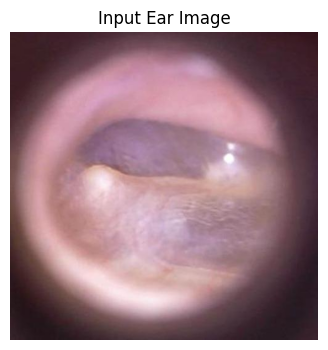

Binary Prediction: Normal
Confidence: 65.56%

Ear looks Normal. No disease detected.


In [ ]:
predict_ear_image("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/norm-354-_jpg.rf.211788b72fb822016cc8bd508e68edb4.jpg")

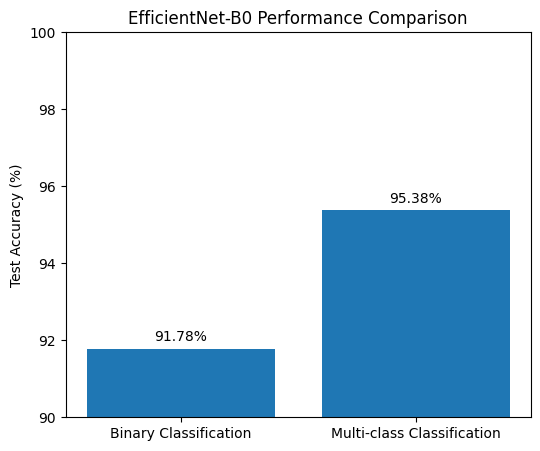

In [ ]:
import matplotlib.pyplot as plt

binary_accuracy = 91.78
multiclass_accuracy = 95.38

models = ['Binary Classification', 'Multi-class Classification']
accuracies = [binary_accuracy, multiclass_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracies)

plt.ylim(90, 100)
plt.ylabel("Test Accuracy (%)")
plt.title("EfficientNet-B0 Performance Comparison")

for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.2,
             f"{accuracies[i]:.2f}%",
             ha='center')

plt.show()
